# Dental X-ray DENTEX YOLO11n-seg + W&B Tracking
> Kaggle T4 GPU | COCO to YOLO | 80/20 split | W&B Logs and Graphs | ONNX export

---
Trained in Kaggle environment using T4 GPU

### Classes
| 0 Caries | 1 Deep Caries | 2 Periapical Lesion | 3 Impacted Tooth |

## Environment Setup

In [1]:
# Install all required packages
!pip install ultralytics supervision --quiet



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.7/48.7 kB 4.1 MB/s eta 0:00:00


In [2]:
!pip install wandb --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.6/25.6 MB 76.9 MB/s eta 0:00:00
  Attempting uninstall: wandb
    Found existing installation: wandb 0.24.0
    Uninstalling wandb-0.24.0:
      Successfully uninstalled wandb-0.24.0


In [3]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("WAND_API")


In [4]:
# print(secret_value_0)

In [5]:
import torch
import wandb

print(f'PyTorch  : {torch.__version__}')
print(f'W&B      : {wandb.__version__}')

if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('No GPU detected. Go to Settings > Accelerator > GPU T4')

PyTorch  : 2.9.0+cu126
W&B      : 0.25.1
GPU      : Tesla T4
VRAM     : 15.6 GB


# Global Configuration

In [ ]:
import os, json, shutil, random, yaml
from pathlib import Path
import numpy as np
from PIL import Image
from tqdm.notebook import tqdm

# Dataset root 
DATASET_ROOT  = Path('/kaggle/input/datasets/safalnarshing/dentex')

#  Disease task paths (4-class training) 
TRAIN_SRC_DIR = DATASET_ROOT / 'training_data' / 'training_data' / 'quadrant-enumeration-disease' / 'xrays'
TRAIN_JSON    = DATASET_ROOT / 'training_data' / 'training_data' / 'quadrant-enumeration-disease' / 'train_quadrant_enumeration_disease.json'

# Val is split from train (no separate val JSON exists)
# VAL_SRC_DIR is intentionally None — same xrays folder as train is used during split
VAL_SRC_DIR   = None
VAL_JSON      = None

#  Test paths (LabelMe format, inference only) 
TEST_SRC_DIR   = DATASET_ROOT / 'test_data' / 'disease' / 'input'
TEST_LABEL_DIR = DATASET_ROOT / 'test_data' / 'disease' / 'label'

#  Output paths (writable, ~20GB limit) 
WORKING_DIR   = Path('/kaggle/working')
DATASET_OUT   = WORKING_DIR / 'datasets' / 'dentex'
TRAIN_IMG_DIR = DATASET_OUT / 'images' / 'train'
VAL_IMG_DIR   = DATASET_OUT / 'images' / 'val'
TRAIN_LBL_DIR = DATASET_OUT / 'labels' / 'train'
VAL_LBL_DIR   = DATASET_OUT / 'labels' / 'val'
YAML_PATH     = DATASET_OUT / 'dentex.yaml'

#  Class mapping 
CLASS_NAMES = {0: 'Caries', 1: 'Deep Caries', 2: 'Periapical Lesion', 3: 'Impacted Tooth'}

#  Training hyperparameters 
EPOCHS    = 100
IMG_SIZE  = 640
BATCH     = 8
VAL_SPLIT = 0.20
SEED      = 42

#  W&B configuration 
WANDB_PROJECT  = 'dentex-yolo11-seg'
WANDB_RUN_NAME = 'yolo11n-seg-baseline'
WANDB_ENTITY   = None
WANDB_TAGS     = ['yolo11n', 'seg', 'dentex', 'dental', 'kaggle-t4', f'batch-{BATCH}']

random.seed(SEED)
np.random.seed(SEED)

#  Path verification (safe None checks) 
print(f'Dataset root : {DATASET_ROOT}  exists={DATASET_ROOT.exists()}')
print(f'Train images : exists={TRAIN_SRC_DIR.exists()} | {TRAIN_SRC_DIR}')
print(f'Train JSON   : exists={TRAIN_JSON.exists()}    | {TRAIN_JSON}')
print(f'Val images   : split from train (no separate source dir)')
print(f'Val JSON     : split from train (no separate JSON)')
print(f'Test images  : exists={TEST_SRC_DIR.exists()}  | {TEST_SRC_DIR}')
print(f'Test labels  : exists={TEST_LABEL_DIR.exists()}| {TEST_LABEL_DIR}')
print(f'Output root  : {DATASET_OUT}')
print(f'Epochs: {EPOCHS} | ImgSz: {IMG_SIZE} | Batch: {BATCH}')

Dataset root : /kaggle/input/datasets/safalnarshing/dentex  exists=True
Train images : exists=True | /kaggle/input/datasets/safalnarshing/dentex/training_data/training_data/quadrant-enumeration-disease/xrays
Train JSON   : exists=True    | /kaggle/input/datasets/safalnarshing/dentex/training_data/training_data/quadrant-enumeration-disease/train_quadrant_enumeration_disease.json
Val images   : split from train (no separate source dir)
Val JSON     : split from train (no separate JSON)
Test images  : exists=True  | /kaggle/input/datasets/safalnarshing/dentex/test_data/disease/input
Test labels  : exists=True| /kaggle/input/datasets/safalnarshing/dentex/test_data/disease/label
Output root  : /kaggle/working/datasets/dentex
Epochs: 100 | ImgSz: 640 | Batch: 8


# W&B Login
Reads the API key from the Kaggle Secret `WANDB_API_KEY`. No key stored in plain text.

In [8]:
# wandb.login()
wandb.login(key=secret_value_0, relogin=True)

print('W&B authenticated successfully')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: safalnarshing (safalnarshing-kathmandu-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B authenticated successfully


# COCO JSON to YOLO TXT Conversion

In [10]:
def coco_bbox_to_yolo(bbox, img_w, img_h):
    x_min, y_min, w, h = bbox
    xc = min(max((x_min + w / 2) / img_w, 0.0), 1.0)
    yc = min(max((y_min + h / 2) / img_h, 0.0), 1.0)
    nw = min(max(w / img_w, 0.0), 1.0)
    nh = min(max(h / img_h, 0.0), 1.0)
    return xc, yc, nw, nh

def coco_segmentation_to_yolo(segmentation, img_w, img_h):
    if not segmentation or not isinstance(segmentation[0], list):
        return None
    poly = segmentation[0]
    if len(poly) < 6:
        return None
    coords = []
    for i in range(0, len(poly), 2):
        coords.append(min(max(poly[i]   / img_w, 0.0), 1.0))
        coords.append(min(max(poly[i+1] / img_h, 0.0), 1.0))
    return coords

def get_image_dimensions(img_path):
    try:
        with Image.open(img_path) as img:
            return img.width, img.height
    except:
        return None, None

def convert_disease_json_to_yolo(json_path, src_img_dir, out_img_dir, out_lbl_dir, symlink=True):
    """
    Converts DENTEX disease JSON to YOLO format.
    
    DENTEX disease schema (different from standard COCO):
      - Uses 'category_id' (0-indexed) directly as YOLO class
      - 0 = Caries, 1 = Deep Caries, 2 = Periapical Lesion, 3 = Impacted Tooth
      - Has both 'segmentation' polygons and 'bbox'
      - Only annotations with category_id 0-3 are kept
    """
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)

    print(f'  Loading: {json_path.name}')
    with open(json_path) as f:
        coco = json.load(f)

    # Verify this is the disease JSON
    cats = coco.get('categories', coco.get('categories_1', []))
    print(f'  Categories found: {cats}')
    print(f'  Total images    : {len(coco["images"]):,}')
    print(f'  Total annotations: {len(coco["annotations"]):,}')

    # Build image_id -> annotations map
    id_to_anns = {}
    for ann in coco['annotations']:
        id_to_anns.setdefault(ann['image_id'], []).append(ann)

    # Determine category key — disease JSON uses 'category_id' (0-indexed directly)
    # sample_ann = coco['annotations'][0] if coco['annotations'] else {}
# DENTEX disease JSON uses category_id_3 for disease classification
    # 0=Caries, 1=Deep Caries, 2=Periapical Lesion, 3=Impacted Tooth
    sample_ann = coco['annotations'][0] if coco['annotations'] else {}

    if 'category_id_3' in sample_ann:
        def get_yolo_class(ann):
            cid = ann.get('category_id_3', -1)
            return cid if 0 <= cid <= 3 else None
    elif 'category_id' in sample_ann:
        def get_yolo_class(ann):
            cid = ann.get('category_id', -1)
            return cid if 0 <= cid <= 3 else None
    else:
        raise KeyError(
            f'No disease category key found. Keys: {list(sample_ann.keys())}'
        )

    skipped, processed, no_ann = 0, 0, 0
    split_label = f'{out_img_dir.parts[-2]}/{out_img_dir.parts[-1]}'

    for img_info in tqdm(coco['images'], desc=f'  Converting {split_label}'):
        img_id   = img_info['id']
        filename = img_info['file_name']
        img_w    = img_info.get('width')
        img_h    = img_info.get('height')

        src = src_img_dir / filename
        if not src.exists():
            src = src_img_dir / Path(filename).name
        if not src.exists():
            skipped += 1
            continue

        if not img_w or not img_h:
            img_w, img_h = get_image_dimensions(src)
        if not img_w or not img_h:
            skipped += 1
            continue

        # Symlink image
        dst_img = out_img_dir / Path(filename).name
        if not dst_img.exists():
            if symlink:
                os.symlink(src.resolve(), dst_img)
            else:
                shutil.copy2(src, dst_img)

        # Write YOLO label
        lines = []
        for ann in id_to_anns.get(img_id, []):
            cls = get_yolo_class(ann)
            if cls is None:
                continue
            seg = coco_segmentation_to_yolo(ann.get('segmentation', []), img_w, img_h)
            if seg:
                lines.append(f'{cls} ' + ' '.join(f'{v:.6f}' for v in seg))
            elif ann.get('bbox'):
                xc, yc, w, h = coco_bbox_to_yolo(ann['bbox'], img_w, img_h)
                lines.append(f'{cls} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}')

        dst_lbl = out_lbl_dir / (Path(filename).stem + '.txt')
        dst_lbl.write_text('\n'.join(lines))
        if not lines:
            no_ann += 1
        processed += 1

    print(f'  Done: processed={processed:,} | no_annotation={no_ann:,} | skipped={skipped:,}')
    return processed

print('Conversion functions defined')

Conversion functions defined


# Build Directory Structure + Convert Annotations

In [11]:
def setup_dataset():
    """
    DENTEX disease task has no separate val JSON.
    We split the disease training JSON 80/20 manually.
    Val images come from the same xrays folder as train.
    """
    print('Setting up DENTEX disease dataset...')

    assert TRAIN_JSON.exists(), f'Disease JSON not found: {TRAIN_JSON}'
    assert TRAIN_SRC_DIR.exists(), f'Train images not found: {TRAIN_SRC_DIR}'

    # Load full disease JSON
    with open(TRAIN_JSON) as f:
        coco = json.load(f)

    print(f'  Disease JSON loaded: {len(coco["images"]):,} images, {len(coco["annotations"]):,} annotations')

    # Verify it's the disease JSON (should have category_id not category_id_1)
# Verify it's the disease JSON — accepts either category_id or category_id_3
    sample = coco['annotations'][0]
    has_disease_key = 'category_id_3' in sample or 'category_id' in sample
    if not has_disease_key:
        raise ValueError(
            f'Wrong JSON! Keys: {list(sample.keys())}\n'
            f'Expected category_id_3 or category_id for disease labels.'
        )

    # Quick check: how many annotations have a valid disease label (category_id_3 > 0)
    disease_key = 'category_id_3' if 'category_id_3' in sample else 'category_id'
    disease_anns = [a for a in coco['annotations'] if 0 <= a.get(disease_key, -1) <= 3]
    print(f'  Annotations with valid disease label: {len(disease_anns):,} / {len(coco["annotations"]):,}')

    # 80/20 split by image ID
    all_ids = [img['id'] for img in coco['images']]
    random.shuffle(all_ids)
    split     = int(len(all_ids) * 0.80)
    train_ids = set(all_ids[:split])
    val_ids   = set(all_ids[split:])

    def split_coco(data, ids):
        return {
            **data,
            'images'     : [i for i in data['images']      if i['id'] in ids],
            'annotations': [a for a in data['annotations'] if a['image_id'] in ids],
        }

    # Write temp split JSONs
    tmp_t = WORKING_DIR / '_tmp_disease_train.json'
    tmp_v = WORKING_DIR / '_tmp_disease_val.json'
    tmp_t.write_text(json.dumps(split_coco(coco, train_ids)))
    tmp_v.write_text(json.dumps(split_coco(coco, val_ids)))

    print(f'  Train split: {len(train_ids):,} images')
    print(f'  Val   split: {len(val_ids):,} images')

    # Convert both splits (images come from the same xrays folder)
    convert_disease_json_to_yolo(tmp_t, TRAIN_SRC_DIR, TRAIN_IMG_DIR, TRAIN_LBL_DIR)
    convert_disease_json_to_yolo(tmp_v, TRAIN_SRC_DIR, VAL_IMG_DIR,   VAL_LBL_DIR)

    tmp_t.unlink()
    tmp_v.unlink()

    # Verify output
    n_ti = len(list(TRAIN_IMG_DIR.glob('*')))
    n_vi = len(list(VAL_IMG_DIR.glob('*')))
    n_tl = len(list(TRAIN_LBL_DIR.glob('*.txt')))
    n_vl = len(list(VAL_LBL_DIR.glob('*.txt')))

    # Sanity check: make sure labels are not all empty
    non_empty_train = sum(1 for f in TRAIN_LBL_DIR.glob('*.txt') if f.stat().st_size > 0)
    non_empty_val   = sum(1 for f in VAL_LBL_DIR.glob('*.txt')   if f.stat().st_size > 0)

    print(f'\n  Train : {n_ti:,} images | {n_tl:,} labels | {non_empty_train:,} non-empty')
    print(f'  Val   : {n_vi:,} images | {n_vl:,} labels | {non_empty_val:,} non-empty')

    if non_empty_train == 0:
        raise RuntimeError(
            'All train labels are empty! The disease JSON category_id values '
            'are not mapping to YOLO classes 0-3. Check the categories in the JSON.'
        )

    return n_ti, n_vi

n_train, n_val = setup_dataset()

Setting up DENTEX disease dataset...
  Disease JSON loaded: 705 images, 3,529 annotations
  Annotations with valid disease label: 3,529 / 3,529
  Train split: 564 images
  Val   split: 141 images
  Loading: _tmp_disease_train.json
  Categories found: [{'id': 0, 'name': '1', 'supercategory': '1'}, {'id': 1, 'name': '2', 'supercategory': '2'}, {'id': 2, 'name': '3', 'supercategory': '3'}, {'id': 3, 'name': '4', 'supercategory': '4'}]
  Total images    : 564
  Total annotations: 2,838


  Converting images/train:   0%|          | 0/564 [00:00<?, ?it/s]

  Done: processed=564 | no_annotation=20 | skipped=0
  Loading: _tmp_disease_val.json
  Categories found: [{'id': 0, 'name': '1', 'supercategory': '1'}, {'id': 1, 'name': '2', 'supercategory': '2'}, {'id': 2, 'name': '3', 'supercategory': '3'}, {'id': 3, 'name': '4', 'supercategory': '4'}]
  Total images    : 141
  Total annotations: 691


  Converting images/val:   0%|          | 0/141 [00:00<?, ?it/s]

  Done: processed=141 | no_annotation=7 | skipped=0

  Train : 564 images | 564 labels | 544 non-empty
  Val   : 141 images | 141 labels | 134 non-empty


## Visualize annoted dataset

Found 250 test annotation JSON files


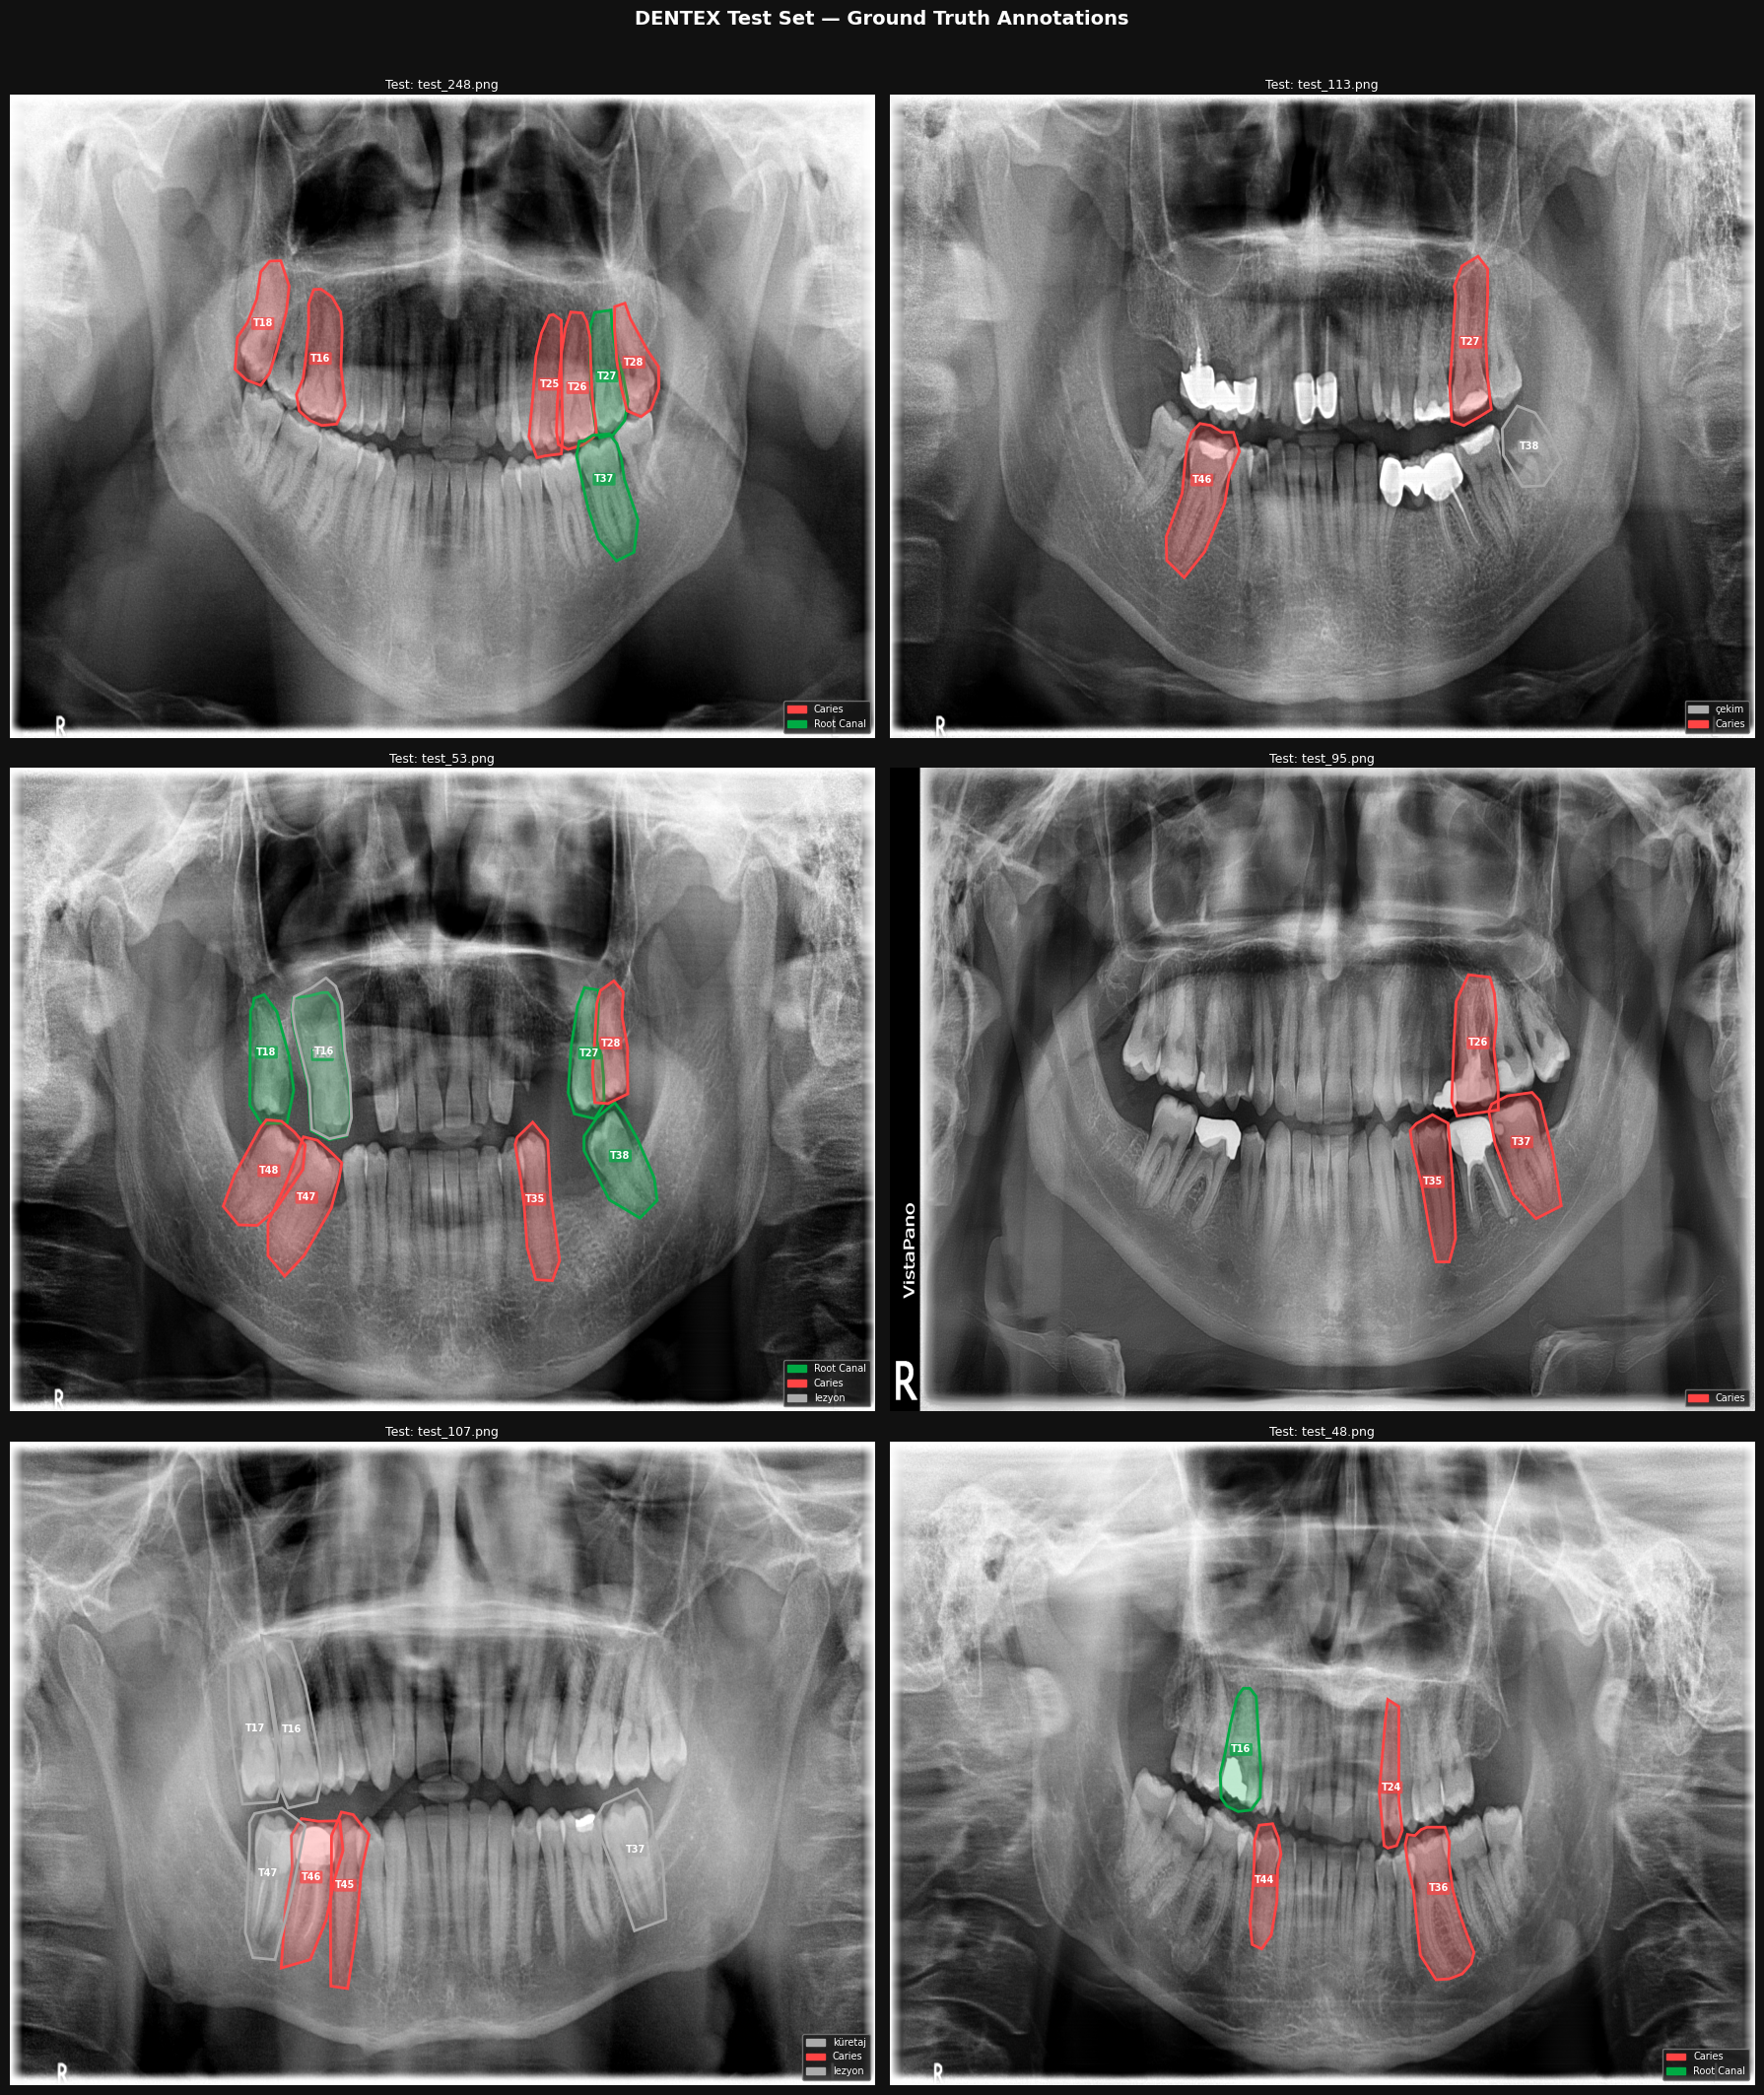

Saved to /kaggle/working/test_annotations_preview.png


In [ ]:
#  Visualize LabelMe annotations from test dataset 
# Paste this as a new cell and run it

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from pathlib import Path
import random
from PIL import Image

#  Label config 
# LabelMe label format: "quadrant-disease_turkish-tooth_number"
# e.g. "1-çürük-15" = quadrant 1, Caries, tooth 15
DISEASE_MAP = {
    'çürük'      : ('Caries',            '#FF4444'),  # red
    'derin çürük': ('Deep Caries',        '#FF8800'),  # orange
    'apse'       : ('Periapical Lesion',  '#AA00FF'),  # purple
    'gömülü'     : ('Impacted Tooth',     '#0088FF'),  # blue
    'kanal'      : ('Root Canal',         '#00AA44'),  # green (extra class in test)
}
# Fallback color for unknown labels
DEFAULT_COLOR = '#AAAAAA'

def parse_labelme_label(label_str):
    """
    Parse LabelMe label string into components.
    Format: 'quadrant-disease_name-tooth_number'
    e.g.  : '1-çürük-15' or '3-kanal-46'
    Returns (quadrant, disease_key, tooth_num, display_name, color)
    """
    parts = label_str.split('-')
    if len(parts) >= 2:
        quadrant  = parts[0]
        # Disease name may contain spaces — join middle parts
        disease   = '-'.join(parts[1:-1]) if len(parts) > 2 else parts[1]
        tooth_num = parts[-1] if len(parts) > 2 else '?'
    else:
        return '?', label_str, '?', label_str, DEFAULT_COLOR

    matched = None
    for key, (name, color) in DISEASE_MAP.items():
        if key in disease.lower():
            matched = (quadrant, key, tooth_num, f'{name} (Q{quadrant} T{tooth_num})', color)
            break

    if not matched:
        matched = (quadrant, disease, tooth_num, f'{disease} (Q{quadrant} T{tooth_num})', DEFAULT_COLOR)

    return matched


def visualize_labelme_xray(json_path, img_dir, ax, title_prefix=''):
    """Load a LabelMe JSON and draw polygons over the X-ray."""
    with open(json_path) as f:
        data = json.load(f)

    img_name = Path(data['imagePath']).name
    img_path = img_dir / img_name

    if not img_path.exists():
        ax.text(0.5, 0.5, f'Image not found:\n{img_name}',
                ha='center', va='center', transform=ax.transAxes, color='red')
        ax.set_title(f'{title_prefix}{img_name}')
        return

    img = np.array(Image.open(img_path).convert('RGB'))
    ax.imshow(img, cmap='gray', aspect='auto')

    legend_patches = {}

    for shape in data['shapes']:
        label_str = shape['label']
        points    = np.array(shape['points'])

        quadrant, disease_key, tooth_num, display_name, color = parse_labelme_label(label_str)

        # Draw filled polygon with transparency
        poly = Polygon(points, closed=True,
                       linewidth=1.5,
                       edgecolor=color,
                       facecolor=color,
                       alpha=0.25)
        ax.add_patch(poly)

        # Draw outline only (solid)
        outline = Polygon(points, closed=True,
                          linewidth=2.0,
                          edgecolor=color,
                          facecolor='none')
        ax.add_patch(outline)

        # Label at centroid
        cx, cy = points[:, 0].mean(), points[:, 1].mean()
        ax.text(cx, cy, f'T{tooth_num}',
                fontsize=7, color='white', fontweight='bold',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.15', facecolor=color, alpha=0.7, edgecolor='none'))

        # Collect for legend (deduplicate by display name)
        disease_label = display_name.split('(')[0].strip()
        if disease_label not in legend_patches:
            legend_patches[disease_label] = mpatches.Patch(color=color, label=disease_label)

    ax.legend(handles=list(legend_patches.values()),
              loc='lower right', fontsize=7,
              framealpha=0.8, facecolor='#1a1a1a', labelcolor='white',
              edgecolor='gray')

    ax.set_title(f'{title_prefix}{img_name}', fontsize=9, color='white', pad=4)
    ax.axis('off')


#  Find test JSON files 
test_label_dir = TEST_LABEL_DIR   # from Cell 2
test_img_dir   = TEST_SRC_DIR     # from Cell 2

json_files = sorted(test_label_dir.glob('*.json'))
print(f'Found {len(json_files)} test annotation JSON files')

if len(json_files) == 0:
    raise FileNotFoundError(
        f'No JSON files found in {test_label_dir}\n'
        f'Contents: {list(test_label_dir.iterdir())[:10]}'
    )

#  Pick samples to visualize 
N_SAMPLES = min(6, len(json_files))
samples   = random.sample(json_files, N_SAMPLES)

#  Plot grid 
cols = 2
rows = (N_SAMPLES + 1) // cols

fig, axes = plt.subplots(rows, cols,
                         figsize=(18, rows * 7),
                         facecolor='#111111')
axes = axes.flatten() if N_SAMPLES > 1 else [axes]

for i, json_path in enumerate(samples):
    visualize_labelme_xray(json_path, test_img_dir, axes[i], title_prefix='Test: ')

# Hide unused subplots
for j in range(N_SAMPLES, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('DENTEX Test Set — Ground Truth Annotations',
             fontsize=14, color='white', y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/test_annotations_preview.png',
            dpi=150, bbox_inches='tight',
            facecolor='#111111')
plt.show()
print('Saved to /kaggle/working/test_annotations_preview.png')

# Disk Check

In [13]:
# Disk check: symlinks keep /kaggle/working usage minimal
!echo '=== /kaggle/working usage (symlinks keep this small) ==='
!du -sh /kaggle/working/*
!echo ''
!echo '=== Total disk available ==='
!df -h /kaggle/working

=== /kaggle/working usage (symlinks keep this small) ===
5.5M	/kaggle/working/datasets
4.1M	/kaggle/working/__notebook__.ipynb
6.1M	/kaggle/working/test_annotations_preview.png

=== Total disk available ===
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G   16M   20G   1% /kaggle/working


# Generate dentex.yaml

In [14]:
yaml_content = {
    'path'  : str(DATASET_OUT),
    'train' : 'images/train',
    'val'   : 'images/val',
    'nc'    : 4,
    'names' : {0: 'Caries', 1: 'Deep Caries', 2: 'Periapical Lesion', 3: 'Impacted Tooth'},
}
with open(YAML_PATH, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)

print(f'YAML saved to: {YAML_PATH}')
print(YAML_PATH.read_text())

YAML saved to: /kaggle/working/datasets/dentex/dentex.yaml
path: /kaggle/working/datasets/dentex
train: images/train
val: images/val
nc: 4
names:
  0: Caries
  1: Deep Caries
  2: Periapical Lesion
  3: Impacted Tooth



## Initialize W&B Run

This starts a single W&B run that stays open through training, validation, and evaluation.
All metrics from all phases will appear in the **same run** on your W&B dashboard under:
- **Charts tab**: loss curves, mAP curves, LR schedule, per-class AP
- **Media tab**: confusion matrix, PR curve, F1 curve, prediction samples
- **Config tab**: all hyperparameters
- **Artifacts tab**: best.pt, ONNX model, dentex.yaml

In [15]:
import wandb
import torch

run = wandb.init(
    project = WANDB_PROJECT,
    name    = WANDB_RUN_NAME,
    entity  = WANDB_ENTITY,
    tags    = WANDB_TAGS,
    notes   = 'YOLO11n-seg on DENTEX dental X-ray 4-class disease detection',

    # All hyperparameters logged here appear in the Config tab
    # and can be used later for W&B Sweeps (hyperparameter search)
    config = {
        # Model
        'model'         : 'yolo11n-seg',
        'task'          : 'segment',
        'pretrained'    : True,

        # Training
        'epochs'        : EPOCHS,
        'imgsz'         : IMG_SIZE,
        'batch'         : BATCH,
        'optimizer'     : 'SGD',
        'lr0'           : 0.01,
        'lrf'           : 0.01,
        'weight_decay'  : 0.0005,
        'warmup_epochs' : 3,
        'patience'      : 15,
        'amp'           : True,
        'dropout'       : 0.1,

        # Augmentation (X-ray tuned: no color jitter)
        'flipud'        : 0.3,
        'fliplr'        : 0.5,
        'degrees'       : 10,
        'translate'     : 0.1,
        'scale'         : 0.3,
        'mosaic'        : 0.5,
        'hsv_h'         : 0.0,
        'hsv_s'         : 0.0,
        'hsv_v'         : 0.2,

        # Dataset
        'dataset'       : 'DENTEX-disease',
        'num_classes'   : 4,
        'class_names'   : list(CLASS_NAMES.values()),
        'train_images'  : n_train,
        'val_images'    : n_val,
        'val_split'     : VAL_SPLIT,
        'seed'          : SEED,

        # Hardware
        'gpu'           : torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU',
        'workers'       : 2,
        'cache'         : False,
    },
)

print(f'W&B run initialized')
print(f'  Run ID  : {run.id}')
print(f'  Run URL : {run.url}')


wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260314_044016-f3tn3xqy
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run yolo11n-seg-baseline
wandb: ⭐️ View project at https://wandb.ai/safalnarshing-kathmandu-university/dentex-yolo11-seg
wandb: 🚀 View run at https://wandb.ai/safalnarshing-kathmandu-university/dentex-yolo11-seg/runs/f3tn3xqy


W&B run initialized
  Run ID  : f3tn3xqy
  Run URL : https://wandb.ai/safalnarshing-kathmandu-university/dentex-yolo11-seg/runs/f3tn3xqy


## Train YOLO11n-seg


In [16]:
from ultralytics import YOLO

# Tell Ultralytics which W&B project/run to log into
# Ultralytics auto-detects the active wandb run and logs:
#   train/box_loss, train/seg_loss, train/cls_loss, train/dfl_loss
#   val/box_loss,   val/seg_loss,   val/cls_loss,   val/dfl_loss
#   metrics/mAP50(B), metrics/mAP50-95(B)  <- box metrics
#   metrics/mAP50(M), metrics/mAP50-95(M)  <- mask/seg metrics
#   metrics/precision(B), metrics/recall(B)
#   lr/pg0, lr/pg1, lr/pg2
os.environ['WANDB_PROJECT'] = WANDB_PROJECT
os.environ['WANDB_NAME']    = WANDB_RUN_NAME

# Load YOLO11n-seg (downloads ~6MB pretrained weights automatically)
# model = YOLO('yolo11n-seg.pt')
model = YOLO('yolo11s-seg.pt')  # 9.4M params, ~+5-8 mAP expected

train_results = model.train(
    data         = str(YAML_PATH),
    epochs       = EPOCHS,
    patience = 20,
    cos_lr    = True,
    imgsz        = IMG_SIZE,
    batch        = BATCH,
    device       = 0,
    workers      = 2,            # Low: Kaggle shared CPU cores
    cache        = False,        # Disabled: 11GB won't fit in 13GB RAM
    amp          = True,         # Mixed precision FP16: saves VRAM
    # patience     = 15,           # Early stopping tolerance
    save         = True,
    save_period  = 10,           # Checkpoint every 10 epochs
    project      = str(WORKING_DIR / 'runs'),
    name         = 'dentex_yolo11n_seg',
    exist_ok     = True,

    # Augmentation tuned for dental X-rays
    flipud       = 0.3,
    fliplr       = 0.5,
    degrees      = 10,
    translate    = 0.1,
    scale        = 0.3,
    mosaic       = 0.5,
    hsv_h        = 0.0,   # No hue: X-rays are grayscale
    hsv_s        = 0.0,   # No saturation
    hsv_v        = 0.2,   # Brightness variation only
    # In Cell 10 training call, add:
    # cls_pw = 2.0,   # upweight rare classes in classification loss

    # Regularization
    dropout      = 0.1,
    weight_decay = 0.0005,
    lr0          = 0.01,
    lrf          = 0.01,
    warmup_epochs= 3,
    cls          = 0.7,
)

best_pt = Path(train_results.save_dir) / 'weights' / 'best.pt'
print(f'Training complete. Best model: {best_pt}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.7, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/datasets/dentex/dentex.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=64

##  Log Training Curves to W&B

Reads Ultralytics `results.csv` and logs all epoch-level metrics as proper W&B line charts
with epoch as the X-axis. This gives you full loss and metric curves in the Charts tab.

In [17]:
import pandas as pd

results_csv = Path(train_results.save_dir) / 'results.csv'

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()  # Remove whitespace from column names
    print(f'Logging {len(df)} epochs of training curves to W&B...')
    print(f'Columns: {list(df.columns)}')

    # Map Ultralytics CSV column names to clean W&B metric names
    # This ensures proper grouping in the W&B Charts tab
    metric_map = {
        # Training losses
        'train/box_loss'        : 'train/loss_box',
        'train/seg_loss'        : 'train/loss_seg',
        'train/cls_loss'        : 'train/loss_cls',
        'train/dfl_loss'        : 'train/loss_dfl',
        # Validation losses
        'val/box_loss'          : 'val/loss_box',
        'val/seg_loss'          : 'val/loss_seg',
        'val/cls_loss'          : 'val/loss_cls',
        'val/dfl_loss'          : 'val/loss_dfl',
        # Box detection metrics (B = bounding box)
        'metrics/precision(B)'  : 'metrics/box_precision',
        'metrics/recall(B)'     : 'metrics/box_recall',
        'metrics/mAP50(B)'      : 'metrics/box_mAP50',
        'metrics/mAP50-95(B)'   : 'metrics/box_mAP50-95',
        # Segmentation metrics (M = mask)
        'metrics/precision(M)'  : 'metrics/seg_precision',
        'metrics/recall(M)'     : 'metrics/seg_recall',
        'metrics/mAP50(M)'      : 'metrics/seg_mAP50',
        'metrics/mAP50-95(M)'   : 'metrics/seg_mAP50-95',
        # Learning rate schedule
        'lr/pg0'                : 'lr/pg0_backbone',
        'lr/pg1'                : 'lr/pg1_head',
        'lr/pg2'                : 'lr/pg2_bias',
    }

    # Log each epoch as a W&B step for proper X-axis alignment
    for _, row in df.iterrows():
        epoch = int(row.get('epoch', _))
        log_dict = {'epoch': epoch}
        for csv_col, wb_key in metric_map.items():
            if csv_col in df.columns and not pd.isna(row.get(csv_col)):
                log_dict[wb_key] = float(row[csv_col])
        wandb.log(log_dict, step=epoch)

    # Identify and log best-epoch summary values to W&B run summary
    # These appear prominently at the top of the W&B run page
    seg_col = 'metrics/mAP50(M)'
    if seg_col in df.columns:
        best_idx = df[seg_col].astype(float).idxmax()
        best_row = df.loc[best_idx]
        wandb.run.summary.update({
            'best_epoch'            : int(best_row.get('epoch', 0)),
            'best_seg_mAP50'        : float(best_row.get('metrics/mAP50(M)',    0)),
            'best_seg_mAP50_95'     : float(best_row.get('metrics/mAP50-95(M)', 0)),
            'best_seg_precision'    : float(best_row.get('metrics/precision(M)', 0)),
            'best_seg_recall'       : float(best_row.get('metrics/recall(M)',    0)),
            'best_box_mAP50'        : float(best_row.get('metrics/mAP50(B)',     0)),
            'best_box_mAP50_95'     : float(best_row.get('metrics/mAP50-95(B)', 0)),
        })
        print(f'Best epoch : {int(best_row.get("epoch", 0))}')
        print(f'Best seg mAP50    : {float(best_row.get("metrics/mAP50(M)", 0)):.4f}')
        print(f'Best seg mAP50-95 : {float(best_row.get("metrics/mAP50-95(M)", 0)):.4f}')

    print(f'Training curves logged to W&B ({len(df)} epochs)')
else:
    print(f'results.csv not found at {results_csv}')

Logging 100 epochs of training curves to W&B...
Columns: ['epoch', 'time', 'train/box_loss', 'train/seg_loss', 'train/cls_loss', 'train/dfl_loss', 'train/sem_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(M)', 'metrics/recall(M)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)', 'val/box_loss', 'val/seg_loss', 'val/cls_loss', 'val/dfl_loss', 'val/sem_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
Best epoch : 90
Best seg mAP50    : 0.4956
Best seg mAP50-95 : 0.3153
Training curves logged to W&B (100 epochs)


#  Full Evaluation on best.pt + Per-Class Metrics

Runs YOLO val on the best saved weights. Logs overall and per-class AP for both
bounding box and segmentation mask, as well as confusion matrix and curve plots.

In [18]:
print('Running full evaluation on best.pt...')

best_model = YOLO(str(best_pt))

eval_metrics = best_model.val(
    data    = str(YAML_PATH),
    imgsz   = IMG_SIZE,
    batch   = BATCH,
    device  = 0,
    verbose = True,
    plots   = True,   # Saves confusion_matrix, PR_curve, F1_curve to save_dir
)

class_names = list(CLASS_NAMES.values())

# Extract per-class AP arrays from eval results
seg_ap50 = eval_metrics.seg.ap50 if hasattr(eval_metrics.seg, 'ap50') else []
seg_ap   = eval_metrics.seg.ap   if hasattr(eval_metrics.seg, 'ap')   else []
box_ap50 = eval_metrics.box.ap50 if hasattr(eval_metrics.box, 'ap50') else []
box_ap   = eval_metrics.box.ap   if hasattr(eval_metrics.box, 'ap')   else []

# Build the eval log dict: overall + per-class metrics
eval_log = {
    # Overall segmentation
    'eval/seg_mAP50'     : eval_metrics.seg.map50,
    'eval/seg_mAP50-95'  : eval_metrics.seg.map,
    'eval/seg_precision' : eval_metrics.seg.mp,
    'eval/seg_recall'    : eval_metrics.seg.mr,
    # Overall box
    'eval/box_mAP50'     : eval_metrics.box.map50,
    'eval/box_mAP50-95'  : eval_metrics.box.map,
    'eval/box_precision' : eval_metrics.box.mp,
    'eval/box_recall'    : eval_metrics.box.mr,
}

# Per-class AP (each class gets its own W&B metric)
for i, cls_name in enumerate(class_names):
    safe = cls_name.lower().replace(' ', '_')
    if i < len(seg_ap50): eval_log[f'eval/seg_AP50_{safe}']    = float(seg_ap50[i])
    if i < len(seg_ap):   eval_log[f'eval/seg_AP50-95_{safe}'] = float(seg_ap[i])
    if i < len(box_ap50): eval_log[f'eval/box_AP50_{safe}']    = float(box_ap50[i])
    if i < len(box_ap):   eval_log[f'eval/box_AP50-95_{safe}'] = float(box_ap[i])

wandb.log(eval_log)

# Console summary
print('\n=== Evaluation Results ===')
print(f'  Segmentation mAP50     : {eval_metrics.seg.map50:.4f}')
print(f'  Segmentation mAP50-95  : {eval_metrics.seg.map:.4f}')
print(f'  Segmentation Precision : {eval_metrics.seg.mp:.4f}')
print(f'  Segmentation Recall    : {eval_metrics.seg.mr:.4f}')
print(f'  Box mAP50              : {eval_metrics.box.map50:.4f}')
print(f'  Box mAP50-95           : {eval_metrics.box.map:.4f}')
print('\n  Per-class Segmentation AP50:')
for i, cls_name in enumerate(class_names):
    if i < len(seg_ap50):
        print(f'    [{cls_name:<20}] {seg_ap50[i]:.4f}')
print('\nEvaluation metrics logged to W&B')

Running full evaluation on best.pt...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s-seg summary (fused): 114 layers, 10,068,364 parameters, 0 gradients, 32.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1789.8±1100.3 MB/s, size: 3795.8 KB)
val: Scanning /kaggle/working/datasets/dentex/labels/val.cache... 141 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 141/141 59.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 2.6it/s 7.0s
                   all        141        691      0.498      0.551      0.531      0.358       0.44      0.521      0.495      0.313
                Caries         46        108      0.767      0.889      0.901      0.581      0.762      0.889      0.901      0.555
           Deep Caries        125        468      0.459      0.361      0.435      0.314       0.42      0.417      0.434 

## Log Plots and Prediction Samples to W&B

Uploads confusion matrix, PR curve, F1 curve, and prediction vs ground truth
image panels to the W&B Media tab.


In [19]:
eval_save_dir  = Path(eval_metrics.save_dir)
train_save_dir = Path(train_results.save_dir)
logged_plots   = 0

# Evaluation plots: confusion matrix, PR curve, F1, precision, recall curves
eval_plot_files = {
    'confusion_matrix.png'          : 'eval/confusion_matrix',
    'confusion_matrix_normalized.png': 'eval/confusion_matrix_normalized',
    'PR_curve.png'                  : 'eval/PR_curve',
    'F1_curve.png'                  : 'eval/F1_curve',
    'P_curve.png'                   : 'eval/precision_curve',
    'R_curve.png'                   : 'eval/recall_curve',
}

for filename, wb_key in eval_plot_files.items():
    # Check both eval and train save dirs (Ultralytics location varies by version)
    for search_dir in [eval_save_dir, train_save_dir]:
        plot_path = search_dir / filename
        if plot_path.exists():
            caption = filename.replace('_', ' ').replace('.png', '')
            wandb.log({wb_key: wandb.Image(str(plot_path), caption=caption)})
            print(f'  Logged: {wb_key}')
            logged_plots += 1
            break

# Training overview plots
train_plot_files = {
    'results.png'             : 'train/results_overview',
    'labels.jpg'              : 'dataset/label_distribution',
    'labels_correlogram.jpg'  : 'dataset/label_correlogram',
}

for filename, wb_key in train_plot_files.items():
    plot_path = train_save_dir / filename
    if plot_path.exists():
        wandb.log({wb_key: wandb.Image(str(plot_path))})
        print(f'  Logged: {wb_key}')
        logged_plots += 1

# Sample predictions vs ground truth (val_batch images saved by Ultralytics)
pred_images, gt_images = [], []
for pred_path in sorted(train_save_dir.glob('val_batch*_pred.jpg'))[:4]:
    pred_images.append(wandb.Image(str(pred_path), caption=pred_path.stem))
for gt_path in sorted(train_save_dir.glob('val_batch*_labels.jpg'))[:4]:
    gt_images.append(wandb.Image(str(gt_path), caption=gt_path.stem))

if pred_images:
    wandb.log({'eval/sample_predictions': pred_images})
    print(f'  Logged {len(pred_images)} prediction samples')
if gt_images:
    wandb.log({'eval/ground_truth': gt_images})
    print(f'  Logged {len(gt_images)} ground truth samples')

print(f'\nTotal: {logged_plots} plots + {len(pred_images)} prediction images logged to W&B')

  Logged: eval/confusion_matrix
  Logged: eval/confusion_matrix_normalized
  Logged: train/results_overview
  Logged: dataset/label_distribution
  Logged 3 prediction samples
  Logged 3 ground truth samples

Total: 4 plots + 3 prediction images logged to W&B


Found 250 test images
WARNING ⚠️ Model does not support 'augment=True', reverting to single-scale prediction.
WARNING ⚠️ Model does not support 'augment=True', reverting to single-scale prediction.
WARNING ⚠️ Model does not support 'augment=True', reverting to single-scale prediction.
WARNING ⚠️ Model does not support 'augment=True', reverting to single-scale prediction.


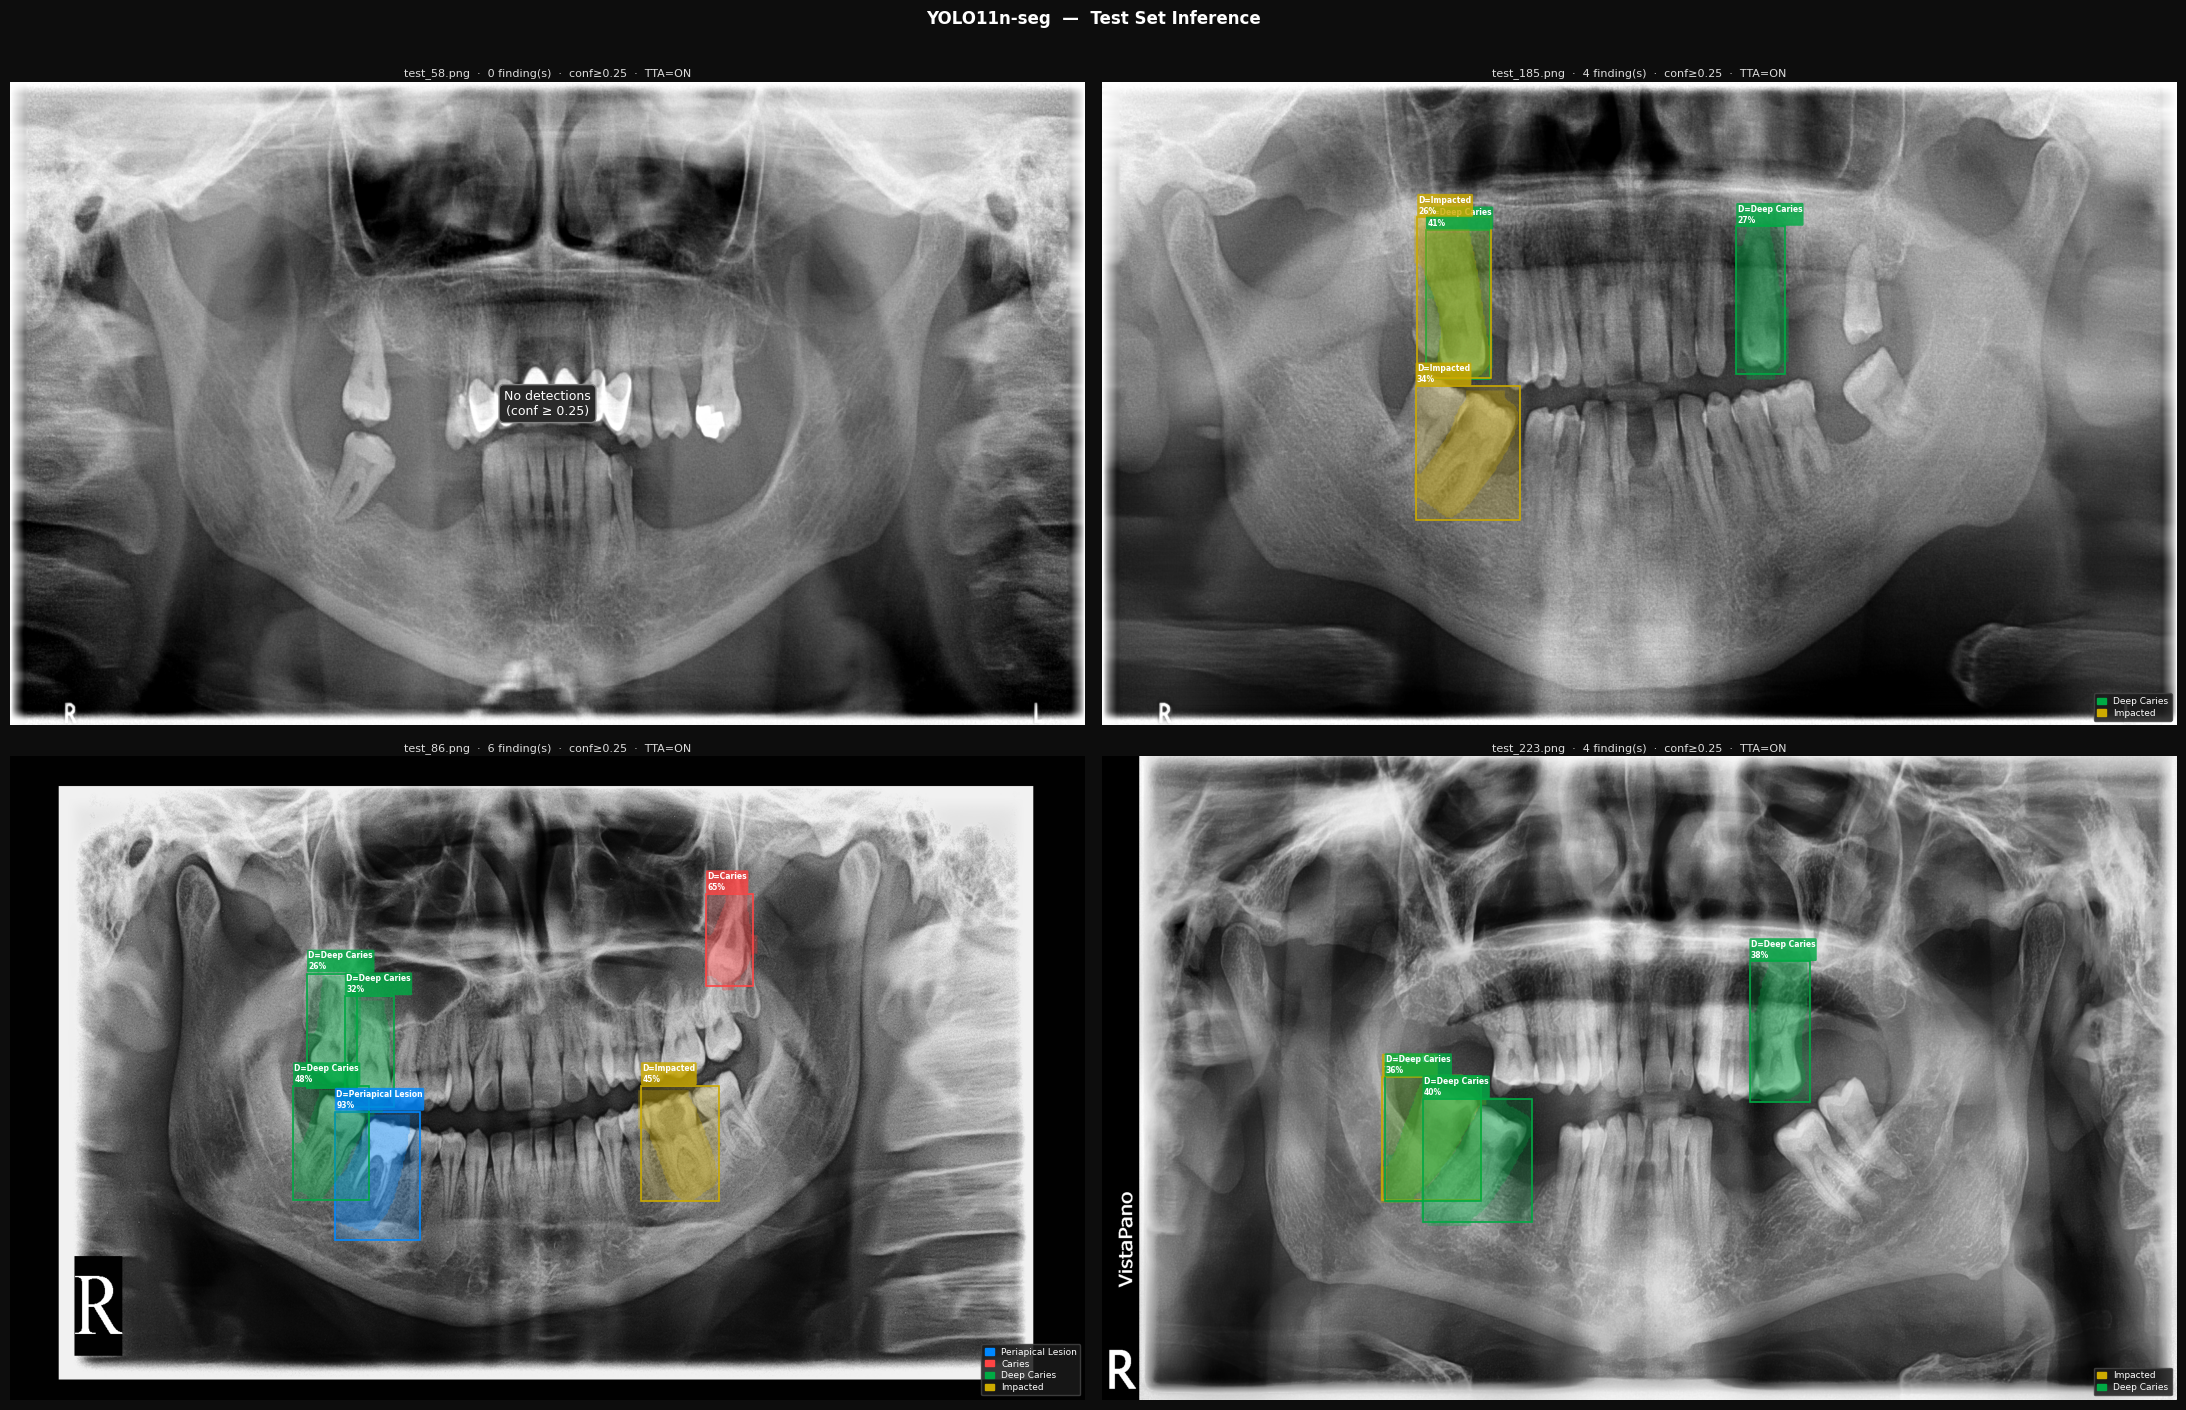

Saved → /kaggle/working/test_inference_preview.png


In [ ]:
#  Cell 13.5 — Test Inference with TTA (compact labels like reference) 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image
import random

CLASS_COLORS = {
    0: '#FF4444',   # Caries — red
    1: '#00AA44',   # Deep Caries — green
    2: '#0088FF',   # Periapical Lesion — blue
    3: '#CCAA00',   # Impacted Tooth — yellow
}
CLASS_SHORT = {
    0: 'Caries',
    1: 'Deep Caries',
    2: 'Periapical Lesion',
    3: 'Impacted',
}
CONF_THRESHOLD = 0.25

#  Pick sample test images 
test_images = list(TEST_SRC_DIR.glob('*.png')) + list(TEST_SRC_DIR.glob('*.jpg'))
print(f'Found {len(test_images)} test images')
if not test_images:
    raise FileNotFoundError(f'No images found in {TEST_SRC_DIR}')

samples    = random.sample(test_images, min(4, len(test_images)))
cols, rows = 2, (len(samples) + 1) // 2
fig, axes  = plt.subplots(rows, cols, figsize=(22, rows * 7), facecolor='#0d0d0d')
axes       = axes.flatten() if len(samples) > 1 else [axes]

for i, img_path in enumerate(samples):
    ax  = axes[i]
    img = np.array(Image.open(img_path).convert('RGB'))
    h, w = img.shape[:2]

    ax.imshow(img, aspect='auto')
    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)

    #  Run inference with TTA 
    results = best_model.predict(
        source  = str(img_path),
        conf    = CONF_THRESHOLD,
        augment = True,
        verbose = False,
        save    = False,
    )
    r = results[0]

    legend_patches = {}
    n_det = 0

    if r.boxes is not None and len(r.boxes) > 0:
        for j in range(len(r.boxes)):
            cls   = int(r.boxes[j].cls)
            conf  = float(r.boxes[j].conf)
            color = CLASS_COLORS.get(cls, '#AAAAAA')
            label = CLASS_SHORT.get(cls, f'C{cls}')
            x1, y1, x2, y2 = r.boxes[j].xyxy[0].tolist()
            bw = x2 - x1
            bh = y2 - y1

            #  Filled + outlined bounding box 
            rect_fill = plt.Rectangle(
                (x1, y1), bw, bh,
                linewidth=0, facecolor=color, alpha=0.20
            )
            rect_line = plt.Rectangle(
                (x1, y1), bw, bh,
                linewidth=1.2, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect_fill)
            ax.add_patch(rect_line)

            #  Segmentation mask if available 
            if r.masks is not None and j < len(r.masks):
                pts = r.masks[j].xy
                if pts is not None and len(pts) > 0 and len(pts[0]) >= 3:
                    from matplotlib.patches import Polygon as MPoly
                    poly = MPoly(pts[0], closed=True,
                                 linewidth=0, facecolor=color, alpha=0.30)
                    ax.add_patch(poly)

            #  Compact label: placed just above box top-left 
            # Format matches reference image: "D=Caries\n52%"
            ann_text = f'D={label}\n{conf:.0%}'

            # Push label above box; if too close to top edge, place inside
            label_y = y1 - 4 if y1 > 30 else y1 + bh * 0.15

            ax.text(
                x1 + 3, label_y,
                ann_text,
                fontsize      = 5.5,
                color         = 'white',
                fontweight    = 'bold',
                va            = 'bottom',
                ha            = 'left',
                linespacing   = 1.3,
                bbox          = dict(
                    boxstyle  = 'round,pad=0.18',
                    facecolor = color,
                    alpha     = 0.82,
                    edgecolor = 'none',
                    linewidth = 0,
                )
            )

            if label not in legend_patches:
                legend_patches[label] = mpatches.Patch(
                    color=color, label=label
                )
            n_det += 1

    else:
        ax.text(
            0.5, 0.5,
            f'No detections\n(conf ≥ {CONF_THRESHOLD})',
            ha='center', va='center',
            transform=ax.transAxes,
            color='white', fontsize=9,
            bbox=dict(facecolor='#2a2a2a', edgecolor='gray',
                      boxstyle='round,pad=0.4')
        )

    #  Legend — bottom right, compact 
    if legend_patches:
        ax.legend(
            handles    = list(legend_patches.values()),
            loc        = 'lower right',
            fontsize   = 6.5,
            framealpha = 0.85,
            facecolor  = '#1a1a1a',
            labelcolor = 'white',
            edgecolor  = '#444444',
            handlelength = 1.0,
            borderpad    = 0.4,
            labelspacing = 0.3,
        )

    #  Title 
    ax.set_title(
        f'{img_path.name}  ·  {n_det} finding(s)  ·  conf≥{CONF_THRESHOLD}  ·  TTA=ON',
        fontsize=8, color='#dddddd', pad=4
    )
    ax.axis('off')

# Hide unused axes
for j in range(len(samples), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'YOLO11n-seg  —  Test Set Inference',
    fontsize=12, color='white', fontweight='bold', y=1.005
)
plt.tight_layout(pad=1.2)

out_path = WORKING_DIR / 'test_inference_preview.png'
plt.savefig(out_path, dpi=180, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print(f'Saved → {out_path}')

## Export to ONNX + Log as W&B Artifact

In [21]:
print('Exporting best.pt to ONNX...')

export_path = best_model.export(
    format   = 'onnx',
    imgsz    = IMG_SIZE,
    dynamic  = True,    # Variable batch size for flexible deployment
    simplify = True,    # Simplify ONNX graph for serving
    opset    = 17,      # Opset 17: compatible with TensorRT, OpenVINO, ONNX Runtime Web
)

onnx_out = WORKING_DIR / 'dentex_yolo11n_seg.onnx'
if export_path and Path(export_path).exists():
    shutil.copy2(export_path, onnx_out)
    size_mb = onnx_out.stat().st_size / 1e6
    print(f'ONNX exported: {onnx_out}  ({size_mb:.1f} MB)')

# Log model files as a versioned W&B Artifact
# This lets you download the model later from the W&B Artifacts tab
artifact = wandb.Artifact(
    name        = 'dentex-yolo11n-seg',
    type        = 'model',
    description = 'YOLO11n-seg trained on DENTEX disease dataset (4-class dental detection)',
    metadata    = {
        'seg_mAP50'    : eval_metrics.seg.map50,
        'seg_mAP50-95' : eval_metrics.seg.map,
        'box_mAP50'    : eval_metrics.box.map50,
        'classes'      : list(CLASS_NAMES.values()),
        'imgsz'        : IMG_SIZE,
        'format'       : 'onnx + pt',
    }
)

artifact.add_file(str(onnx_out),  name='dentex_yolo11n_seg.onnx')
artifact.add_file(str(best_pt),   name='best.pt')
artifact.add_file(str(YAML_PATH), name='dentex.yaml')
wandb.log_artifact(artifact)

print('Model artifact logged to W&B Artifacts tab')

Exporting best.pt to ONNX...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/dentex_yolo11n_seg/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 40, 8400), (1, 32, 160, 160)) (19.6 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 264ms
 Downloaded onnxruntime-gpu
Prepared 2 packages in 2.66s
Installed 2 packages in 12ms
 + onnxruntime-gpu==1.24.3
 + onnxslim==0.1.87

requirements: AutoUpdate success ✅ 3.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 17...
ONNX: slimming with onnxslim 0.1.87...
ONNX: export success

Finish W&B Run + Final Summary

In [22]:
import subprocess

# Save final disk state to W&B run summary
disk = subprocess.run(['df', '-h', '/kaggle/working'], capture_output=True, text=True)
wandb.run.summary['final_disk_usage'] = disk.stdout

# Close the W&B run: flushes all remaining logs and marks run as finished
# After this, the run appears as Finished in the W&B dashboard
run_url = run.url
wandb.finish()

print('\n' + '='*55)
print('  Pipeline Complete!')
print('='*55)
print(f'  PyTorch model  : {best_pt}')
print(f'  ONNX model     : {WORKING_DIR}/dentex_yolo11n_seg.onnx')
print(f'  Training logs  : {train_results.save_dir}')
print(f'  W&B Dashboard  : {run_url}')
print('='*55)

print('\nFinal disk usage:')
!du -sh /kaggle/working/*
!df -h /kaggle/working

wandb: updating run metadata
wandb: 
wandb: Run history:
wandb:                              epoch ▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇████
wandb:            eval/box_AP50-95_caries ▁
wandb:       eval/box_AP50-95_deep_caries ▁
wandb:    eval/box_AP50-95_impacted_tooth ▁
wandb: eval/box_AP50-95_periapical_lesion ▁
wandb:               eval/box_AP50_caries ▁
wandb:          eval/box_AP50_deep_caries ▁
wandb:       eval/box_AP50_impacted_tooth ▁
wandb:    eval/box_AP50_periapical_lesion ▁
wandb:                     eval/box_mAP50 ▁
wandb:                                +34 ...
wandb: 
wandb: Run summary:
wandb:               best_box_mAP50 0.53168
wandb:            best_box_mAP50_95 0.35775
wandb:                   best_epoch 90
wandb:               best_seg_mAP50 0.49556
wandb:            best_seg_mAP50_95 0.31528
wandb:           best_seg_precision 0.48161
wandb:              best_seg_recall 0.49566
wandb:                        epoch 100
wandb:      eval/box_AP50-95_caries 0.58082
wan


  Pipeline Complete!
  PyTorch model  : /kaggle/working/runs/dentex_yolo11n_seg/weights/best.pt
  ONNX model     : /kaggle/working/dentex_yolo11n_seg.onnx
  Training logs  : /kaggle/working/runs/dentex_yolo11n_seg
  W&B Dashboard  : https://wandb.ai/safalnarshing-kathmandu-university/dentex-yolo11-seg/runs/f3tn3xqy

Final disk usage:
6.1M	/kaggle/working/datasets
40M	/kaggle/working/dentex_yolo11n_seg.onnx
9.5M	/kaggle/working/__notebook__.ipynb
671M	/kaggle/working/runs
6.1M	/kaggle/working/test_annotations_preview.png
6.5M	/kaggle/working/test_inference_preview.png
5.5M	/kaggle/working/wandb
20M	/kaggle/working/yolo11s-seg.pt
5.3M	/kaggle/working/yolo26n.pt
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  769M   19G   4% /kaggle/working


## Zip and download

In [23]:
import zipfile
from pathlib import Path

WORKING_DIR = Path('/kaggle/working')
zip_path    = WORKING_DIR / 'dentex_model_export.zip'

# Collect all important files
files_to_zip = [
    *WORKING_DIR.glob('runs/**/weights/best.pt'),
    *WORKING_DIR.glob('runs/**/weights/last.pt'),
    *WORKING_DIR.glob('*.onnx'),
    *WORKING_DIR.glob('datasets/dentex/dentex.yaml'),
    *WORKING_DIR.glob('runs/**/results.csv'),
    *WORKING_DIR.glob('runs/**/results.png'),
    *WORKING_DIR.glob('runs/**/confusion_matrix*.png'),
    *WORKING_DIR.glob('runs/**/PR_curve.png'),
    *WORKING_DIR.glob('runs/**/F1_curve.png'),
    *WORKING_DIR.glob('test_annotations_preview.png'),
]

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in files_to_zip:
        if f.exists():
            # Preserve folder structure inside zip
            zf.write(f, f.relative_to(WORKING_DIR))
            print(f'  Added: {f.relative_to(WORKING_DIR)}')

size_mb = zip_path.stat().st_size / 1e6
print(f'\n✅ Zip created: {zip_path}')
print(f'   Size: {size_mb:.2f} MB')
print(f'   Download from Kaggle Output panel on the right sidebar')

  Added: runs/dentex_yolo11n_seg/weights/best.pt
  Added: runs/dentex_yolo11n_seg/weights/last.pt
  Added: dentex_yolo11n_seg.onnx
  Added: datasets/dentex/dentex.yaml
  Added: runs/dentex_yolo11n_seg/results.csv
  Added: runs/dentex_yolo11n_seg/results.png
  Added: runs/dentex_yolo11n_seg/confusion_matrix_normalized.png
  Added: runs/dentex_yolo11n_seg/confusion_matrix.png
  Added: runs/segment/val/confusion_matrix_normalized.png
  Added: runs/segment/val/confusion_matrix.png
  Added: test_annotations_preview.png

✅ Zip created: /kaggle/working/dentex_model_export.zip
   Size: 79.62 MB
   Download from Kaggle Output panel on the right sidebar
